## Understanding DataSet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading data set to enviroment
dataset = pd.read_excel("Apples_stock price dataset.xlsx", sheet_name="Sheet1")

#Working on a copy
df = dataset.copy()

In [2]:
#Undestanding data
print("\n<-----------INFO---------->\n")
print(df.info())

print("\n<------------DESCRIBE----------->\n")
print(df.describe())

print("\n<------------DESCRIBE ALL CATEGORICAL AND NUMERICAL VALUES----------->\n")
print(df.describe(include='all'))

print("\n<------------CHCKING NULL VALUES----------->\n")
print(df.isnull().sum())

print("\n<------------DUPLICATE VALUES----------->\n")
print(df.duplicated().sum())



<-----------INFO---------->

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   timestamp          100000 non-null  datetime64[ns]
 1   stock_price        99969 non-null   float64       
 2   nasdaq_index       99993 non-null   float64       
 3   sp500_index        99996 non-null   float64       
 4   inflation_rate     99992 non-null   float64       
 5   unemployment_rate  99996 non-null   float64       
 6   interest_rate      99998 non-null   float64       
 7   market_sentiment   99996 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 6.1 MB
None

<------------DESCRIBE----------->

                 timestamp   stock_price   nasdaq_index    sp500_index  \
count               100000  99969.000000   99993.000000   99996.000000   
mean   2015-09-15 07:30:00    299.991904  259114.6225

## Exploratory Data Analysis

#### Univariate Analysis

In [ ]:
numerical_cols = df.select_dtypes(include=['float64']).columns.tolist()

# Histogram and the box plot for different variables
for col in numerical_cols:
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.title(f"Histogram for {col}")
    sns.histplot(df[col], kde=True,bins=20)

    plt.subplot(1,2,2)
    plt.title(f"Boxplot for {col}")
    sns.boxplot(df[col],orient="h")

    plt.show()

#### Bivariate Analysis

In [ ]:
# Checking the potential relation between the variables
for i,x_col in enumerate(numerical_cols):
    for y_col in numerical_cols[i+1:]:
        plt.figure(figsize=(8,5))
        sns.scatterplot(x=x_col, y=y_col, data=df)
        plt.xlabel(x_col)
        plt.ylabel(y_col)

        plt.show()

In [ ]:
# Directly using pairplot to see the relation 
sns.pairplot(df)
plt.show()

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(9,6))
df_new = df.drop(columns=['timestamp'])
sns.heatmap(df_new.corr(),annot=True,cmap='viridis')

#### Data Cleaning

In [3]:
# 4:00 AM to 8:00 Pm  consider only and exclude Saturday and sunday
filtered_by_time = df[(df['timestamp'].dt.hour >= 4) & (df['timestamp'].dt.hour <= 20)]

# Removing sturday and sunday 
filtered_by_time_day = filtered_by_time[filtered_by_time['timestamp'].dt.dayofweek < 5]

In [4]:
# Removing the highly correlated variables kepping only one asloremoving the insignificant variables.

"""
- We can clearly see the correlation between the stock_price and 
inflation_rate,unemployment_rate,interest_rate,market_sentiment are nearly zero. Hence,They are insignificant

- Also the correlation between the two independent variables i.e nasdaq_index and sp500_index is strong so we can drop one of them.
Hence, removing sp500_index, inflation_rate, unemployment_rate, interest_rate, market_sentiment.
"""

filtered_data = filtered_by_time_day.drop(columns=['sp500_index','inflation_rate','unemployment_rate','interest_rate','market_sentiment']) 
filtered_data.head(20)

,timestamp,stock_price,nasdaq_index
4,2010-01-01 04:00:00,98.983464,8002.448861
5,2010-01-01 05:00:00,99.022103,8011.832789
6,2010-01-01 06:00:00,108.127409,8028.157784
7,2010-01-01 07:00:00,104.107075,8027.722289
8,2010-01-01 08:00:00,97.961085,8029.541811
9,2010-01-01 09:00:00,103.059812,8040.445418
10,2010-01-01 10:00:00,98.068478,8056.045268
11,2010-01-01 11:00:00,98.095471,8048.212134
12,2010-01-01 12:00:00,101.672484,8029.145300
13,2010-01-01 13:00:00,90.934823,8040.171561


In [5]:
filtered_data = filtered_data.set_index('timestamp')
filtered_data.head(20)

,stock_price,nasdaq_index
timestamp,,
2010-01-01 04:00:00,98.983464,8002.448861
2010-01-01 05:00:00,99.022103,8011.832789
2010-01-01 06:00:00,108.127409,8028.157784
2010-01-01 07:00:00,104.107075,8027.722289
2010-01-01 08:00:00,97.961085,8029.541811
2010-01-01 09:00:00,103.059812,8040.445418
2010-01-01 10:00:00,98.068478,8056.045268
2010-01-01 11:00:00,98.095471,8048.212134
2010-01-01 12:00:00,101.672484,8029.145300


In [6]:
filtered_data.index.is_unique

True

In [7]:
# Treating outliers
# As we can see clearly from the boxplot above only the stock_price has outliers so, we will only treat that column.
Q1 = filtered_data["stock_price"].quantile(0.25)
Q3 = filtered_data["stock_price"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - IQR*1.5
upper_limit  = Q3 + IQR*1.5

outliers = (filtered_data["stock_price"] > upper_limit) | (filtered_data["stock_price"] < lower_limit)

# Total number of outliers in filtered_data
print(outliers.sum())

# Clipping outliers 
# Clipping the outliers those have higer value than upper_limit value with upper_limit
filtered_data[filtered_data["stock_price"] > upper_limit] = upper_limit  
# Clipping the outliers those have lower value than lower_limit value with lower_limit
filtered_data[filtered_data["stock_price"] < lower_limit] = lower_limit 

77


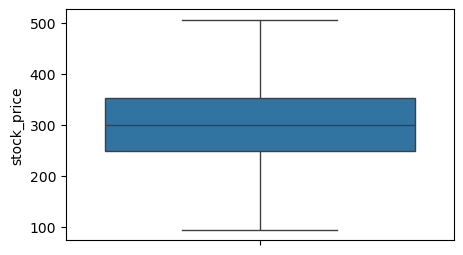

In [8]:
# Checking whethere outliers are successfully removed or not ---> using box plot 
plt.figure(figsize=(5,3))
sns.boxplot(filtered_data["stock_price"])
plt.show()

### Data Preprocessing

In [9]:
filtered_data.isnull().sum()

stock_price     18
nasdaq_index     4
dtype: int64

In [10]:
# Filling the missing values with appropriate value
filtered_data["stock_price"].fillna(method="ffill", inplace=True)

# As there is no outliers in the nasdaq_indexwecan fill them with mean.
filtered_data.fillna({"nasdaq_index":filtered_data["nasdaq_index"].mean()}, inplace=True)


C:\Users\mdrud\AppData\Local\Temp\ipykernel_9872\1213479592.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_data["stock_price"].fillna(method="ffill", inplace=True)
C:\Users\mdrud\AppData\Local\Temp\ipykernel_9872\1213479592.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filtered_data["stock_price"].fillna(method="ffill", inplace=True)


In [11]:
# Verifying whether the null values are filled or not.
filtered_data.isnull().sum()

stock_price     0
nasdaq_index    0
dtype: int64

#### Splitting The DataSet Into Target And The Independent Variables

In [12]:
y = filtered_data["stock_price"] # Target variable
X = filtered_data.drop(columns=["stock_price"]) # Independent variable

### ADF(Augmented Dicky Fuller) Test

In [17]:
# To check the time series data is stationary or not -----> ADF test
from statsmodels.tsa.stattools import adfuller

result = adfuller(y)
print("ADF statistic: ",result[0])
print("p-value is given by:", result[1])
print("critical value is given by:", result[4])

if result[1] < 0.05:
    print("Series is stationary, no differencing is needed (d=0)")
else:
    print("Series is non stationary - Hence, differencing is needed (d=1)")

ADF statistic:  -0.4483841074562198
p-value is given by: 0.9017015650334818
critical value is given by: {'1%': np.float64(-3.4304793772551894), '5%': np.float64(-2.861597182103375), '10%': np.float64(-2.5668004361400687)}
Series is non stationary - Hence, differencing is needed (d=1)


### ACF And PACF 

In [ ]:
# Plotting acf and pacf to find the values of the p and q
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA

plot_acf(y)
plot_pacf(y)
plt.show()

### Conclusion drawn from graphs:
```
i. As we can see in the pacf graph there is a clear cuts off  at lag 1, hence choose p = 1
ii. In acf there is no clear cuts off in any lags so we can choose the q = 0. Also we will check taking q = 1
```

### Scalling Independent variables

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_X =pd.DataFrame(scaler.fit_transform(X), columns= X.columns, index = X.index)

"""
chossing the manual splitting instead of using train_test_split because,
in case of train_test_split the data is being overlapped with each other which is bad in time_series.
"""

split_point = int(len(y) * 0.8)
X_train, X_test = scaled_X.iloc[:split_point], scaled_X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]


## Model Bulding

#### Univariate Time-series Models: ARIMA & SARIMA
```
Univariate models are the statistical or mathematical models that considers only one variable for analysis or forecasting.
Here, That one variable is stock_price.
```

#### ARIMA Model:

In [14]:
# Making a function that will help to check evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
def evaluate(actual,pred):
    mse = mean_squared_error(pred,actual)
    mae = mean_absolute_error(pred,actual)
    r2 = r2_score(pred,actual)
    rmse = np.sqrt(mse)
    print("Root_mean_squared_error is given by:",rmse)
    print("Mean_absolute_error is given by:",mse)
    print("r2_score is given by:",r2)
    

In [15]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(y_train,order=(1,1,0))
arima_result = model_arima.fit()

print(arima_result.summary())

C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            stock_price   No. Observations:                40473
Model:                 ARIMA(1, 1, 0)   Log Likelihood             -140567.368
Date:                Thu, 30 Oct 2025   AIC                         281138.735
Time:                        18:40:24   BIC                         281155.952
Sample:                             0   HQIC                        281144.182
                              - 40473                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4999      0.001   -369.360      0.000      -0.503      -0.497
sigma2        60.8578      0.111    546.082      0.000      60.639      61.076
Ljung-Box (L1) (Q):                1132.86   Jarque-

In [18]:
# Applying the ADF test on model residuals to check whether the data became stationary or not

# Extracting Residuals
residuals = arima_result.resid
# Running ADF Test on the residuals
result_residuals = adfuller(residuals)

# p-values is given by
p_value = result_residuals[1]
significance_value = 0.05

if p_value < 0.05:
    print("The residuals are stationary, No need to adjust the p, q again ")
else:
    print("The residuals are non stationary - Hence, Adjustment of pand q is needed")

The residuals are stationary, No need to adjust the p, q again 


C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


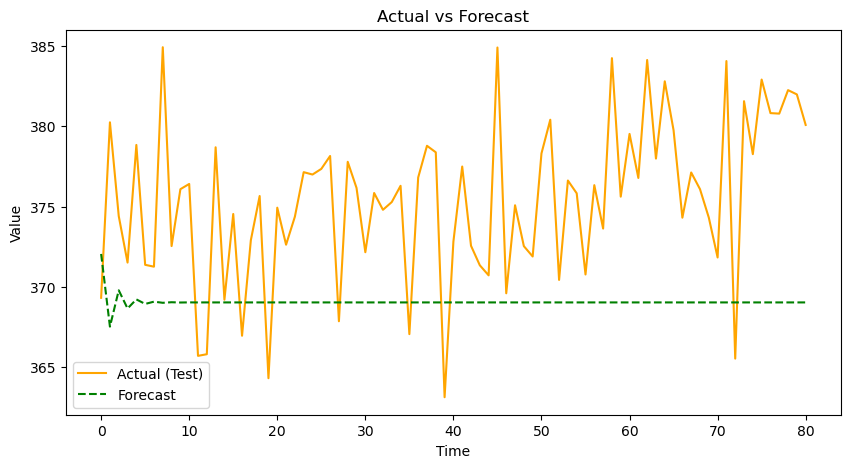

Root_mean_squared_error is given by: 74.14344204157314
Mean_absolute_error is given by: 5497.2499977721145
r2_score is given by: -4589198.781941686


In [19]:
# Generate forecast for 80 steps
forecast = arima_result.forecast(len(y_test))

# For better view chossing only 80 records from the y_test and forecast
actual = y_test.iloc[:81] # Choosing first 80 values from the y_test data.
pred   = forecast.iloc[:81] # Taking 80 records from the predicted dataset


plt.figure(figsize=(10,5))
plt.plot(actual.values, label="Actual (Test)", color='orange')
plt.plot(pred.values, label="Forecast", color='green', linestyle='--')
plt.legend()
plt.title("Actual vs Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# Evalution metrics
evaluate(y_test,forecast)

In [ ]:
# Checking model with q=1
model_arima2 = ARIMA(y_train,order=(1,1,1))
arima_fit = model_arima2.fit()

print(arima_fit.summary())

In [ ]:
forecast = arima_fit.forecast(len(y_test))


actual = y_test.iloc[:81] # Choosing first 80 values from the y_test data.
pred   = forecast.iloc[:81] # Taking 80 records from the predicted dataset

plt.figure(figsize=(10,5))
plt.plot(actual.values, label="Actual (Test)", color='orange')
plt.plot(pred.values, label="Forecast", color='green', linestyle='--')
plt.legend()
plt.title("Actual vs Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# Evalution of model
evaluate(y_test,forecast)

#### SARIMA Model: (Univariate model)

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Consideing q = 0 cause it is better as compared to the q=1 as we can see above.
# Seasonal order 16, cause here we are considering day wise flactuation. As each day consists of 16 hrs of data so s=16.
model_sarima = SARIMAX(y_train, order=(1,1,0),seasonal_order=(1,1,0,16)) 
sarima_fit = model_sarima.fit()

print(sarima_fit.summary())

C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        stock_price   No. Observations:                40473
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 16)   Log Likelihood             -148595.575
Date:                            Thu, 30 Oct 2025   AIC                         297197.149
Time:                                    19:14:32   BIC                         297222.973
Sample:                                         0   HQIC                        297205.319
                                          - 40473                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4997      0.002   -274.565      0.000      -0.503      -0.496
ar.S.L16      -0.4954      0.002   

C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


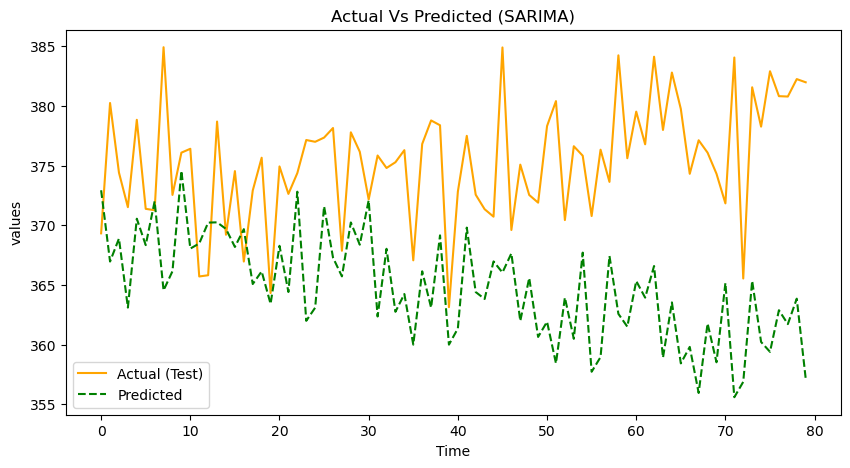

Root_mean_squared_error is given by: 867.1377466758374
Mean_absolute_error is given by: 751927.8717100489
r2_score is given by: -3.752837367097114


In [21]:
# Forecasting sarima results and compairing with the test data
forecast = sarima_fit.forecast(len(y_test)) 

actual = y_test.iloc[:80]
pred = forecast.iloc[:80]

plt.figure(figsize=(10,5))
plt.plot(actual.values, label="Actual (Test)", color="orange")
plt.plot(pred.values,label="Predicted", color="green", linestyle='--')
plt.title("Actual Vs Predicted (SARIMA)")
plt.xlabel("Time")
plt.ylabel("values")
plt.legend()
plt.show()

# Evalution of models
evaluate(y_test,forecast)

### Multivariate Time-series Model
```
Multivariate models are the mathematical and statistical models ,where the target variable depends on the multiple independent variables.
Here,stock_price depends on the nasdaq_index,inflation_rate,unemployment_rate,interest_rate and market_sentiment.
- Now, we will go for the advance models those are efficient in handling independent variables not like ARIMA and SARIMA which only works on one varible i.e stock_price.
```

### SARIMAX (ARIMA with exogenous variables):

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(y_train,exog=X_train,order=(1,1,0),seasonal_order=(1,1,0,16))
sarimax_fit = model_sarimax.fit(disp=False)

print(sarimax_fit.summary())

C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        stock_price   No. Observations:                40473
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 16)   Log Likelihood             -148537.344
Date:                            Thu, 30 Oct 2025   AIC                         297082.687
Time:                                    19:51:40   BIC                         297117.119
Sample:                                         0   HQIC                        297093.580
                                          - 40473                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
nasdaq_index    99.5214      2.299     43.296      0.000      95.016     104.027
ar.L1           -0.4997      

C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mdrud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


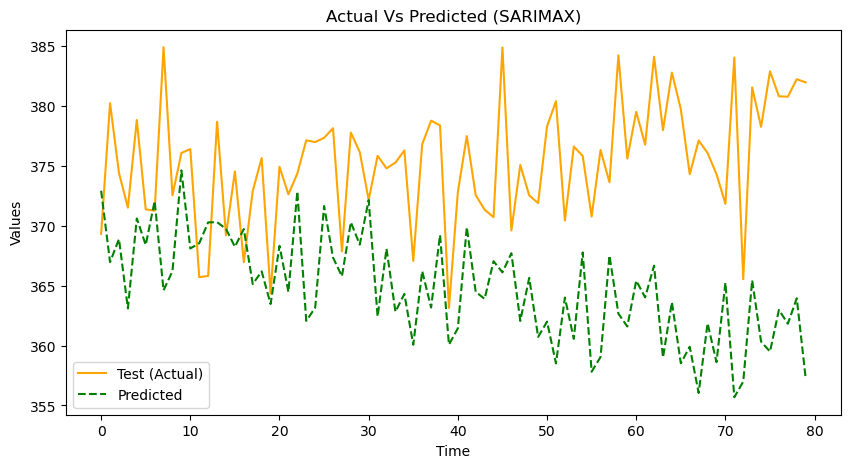

Root_mean_squared_error is given by: 862.4511830623081
Mean_absolute_error is given by: 743822.0431655749
r2_score is given by: -3.753599637612007


In [23]:
forecast = sarimax_fit.forecast(len(y_test),exog=X_test) #Predict 80 values
actual = y_test.iloc[:80]
pred = forecast.iloc[:80]

plt.figure(figsize=(10,5))
plt.plot(actual.values,label="Test (Actual)",color="orange")
plt.plot(pred.values,label="Predicted",color="green", linestyle="--")
plt.title("Actual Vs Predicted (SARIMAX)")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")
plt.show()

# Evaluation of models performance 
evaluate(y_test,forecast)

### VAR(Vector Autoregression) Model:

In [ ]:
from statsmodels.tsa.api import VAR

# Combining the training data of independent and dependent variables because var needs all endogenous variables together.
train= pd.concat([X_train, y_train],axis=1)
# Combining the test data of independent and dependent variables
test = pd.concat([X_test,y_test],axis=1)

model = VAR(train)
lag_order = model.select_order(maxlags=5) # We can also choose different different lag values 10,15 and so on.
print("Lag order selection criteria:\n", lag_order.summary())

best_lag = lag_order.aic # We can also choose BIC, HQIC 
print("Best lag (AIC):", best_lag)

# Ftting model
var_fit = model.fit(best_lag)


In [ ]:
"""
The VAR model predicts future values based on the last best_lag time steps,
so we take those final rows from the training data to generate forecasts.
"""
# Forecasting
forecast_input = train.values[-best_lag:] # because the model needs the last best_lag observations as input to start forecasting.
forecast = var_fit.forecast(y=forecast_input, steps=len(test))

forecast_df = pd.DataFrame(forecast,index=test.index, columns=test.columns)
# TAking 80 steps from the test data and from the predicteddata for the better view
actual = y_test.iloc[:81]
pred = forecast_df[y_train.name].iloc[:81]


plt.figure(figsize=(8,5))
plt.plot(actual.values, label="Actual (Test)", color="orange")
plt.plot(pred.values, label="Predicted (VAR)", color="green")
plt.title("Actual vs Predicted (VAR)")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

# Evalution of models performance
evaluate(y_test,forecast_df["stock_price"])

###  Making Dataset for the models Those Do Not Handle Lags Internally: (Random Forest, XGBOOST etc)

In [28]:
# Making dataset for the models,those does not handle lags internally
new_data_set = filtered_data.copy()
for lag in range(1,5):
    new_data_set[f"lag_{lag}"] = new_data_set["stock_price"].shift(lag)
    
new_data_set.dropna(inplace=True)

In [29]:
# Target and the independent variable for the new_data set 
target_new = new_data_set["stock_price"]
independent_var = new_data_set.drop(columns="stock_price")


# Train test split for new_dataset
length_new = int(len(independent_var)*0.8)
X_train_new, y_train_new = independent_var.iloc[:length_new] , target_new.iloc[:length_new]
X_test_new, y_test_new = independent_var.iloc[length_new:], target_new.iloc[length_new:]

In [30]:
new_data_set

,stock_price,nasdaq_index,lag_1,lag_2,lag_3,lag_4
timestamp,,,,,,
2010-01-01 08:00:00,97.961085,8029.541811,104.107075,108.127409,99.022103,98.983464
2010-01-01 09:00:00,103.059812,8040.445418,97.961085,104.107075,108.127409,99.022103
2010-01-01 10:00:00,98.068478,8056.045268,103.059812,97.961085,104.107075,108.127409
2010-01-01 11:00:00,98.095471,8048.212134,98.068478,103.059812,97.961085,104.107075
2010-01-01 12:00:00,101.672484,8029.145300,98.095471,98.068478,103.059812,97.961085
...,...,...,...,...,...,...
2021-05-28 16:00:00,488.004936,507912.456960,500.825889,498.638436,502.789331,500.370614
2021-05-28 17:00:00,501.413780,507914.215983,488.004936,500.825889,498.638436,502.789331
2021-05-28 18:00:00,492.627037,507927.121232,501.413780,488.004936,500.825889,498.638436


### Random Forest :

In [24]:
from sklearn.model_selection import GridSearchCV,TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

# Time series split ensures training data comes before test data in time
tscv = TimeSeriesSplit(n_splits=5)

# Use GridSearchCV for hyper parameter tunning ---> Helps to find the best parameters
# After using grid search i got the best parameters so, i have used directly in the model for fast processing and reducing run time of the model.
parameters = {      
    'max_depth': 10,             
    'min_samples_split': 2,        
    'min_samples_leaf': 4,         
    'max_features': 'sqrt'         
}
rf_model = RandomForestRegressor(**parameters)

# But again i used grid search for scoring and cross validation by using only one parametere, because without any parameter it will raise error.
# As there is only one parameter it will reduce the running time.
param_grid= {
    'n_estimators': [200] 
}
rf_grid= GridSearchCV(rf_model,param_grid,cv=tscv,scoring='r2')
rf_grid.fit(X_train, y_train) # Randomforest is incensitive towards scaling so we can keep the scaled split here also.


,estimator,RandomForestR...amples_leaf=4)
,param_grid,{'n_estimators': [200]}
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [25]:
y_pred = rf_grid.predict(X_test)


# Evalution of model performance
evaluate(y_test,y_pred)


Root_mean_squared_error is given by: 75.33593189276165
Mean_absolute_error is given by: 5675.502634150822
r2_score is given by: -18.59140839679017


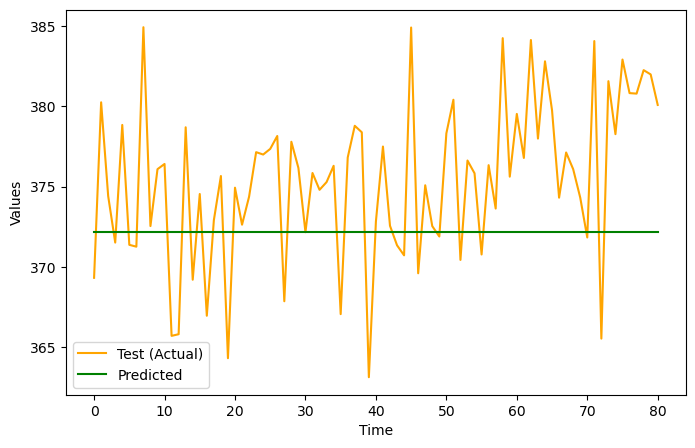

In [26]:
#Plotting graph between test data and the predicted dataset

# Taking 80 step values for the better views of graphs
plt.figure(figsize=(8,5))
plt.plot(y_test.iloc[:81].values,label="Test (Actual)",color="orange")
plt.plot(y_pred[:81],label="Predicted", color="green")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()

### Fitting Model With New Lagged Data Set: (Random Forest)

In [31]:
rf_grid_new = GridSearchCV(rf_model,param_grid,cv=tscv,scoring='r2')
rf_grid_new.fit(X_train_new,y_train_new)

,estimator,RandomForestR...amples_leaf=4)
,param_grid,{'n_estimators': [200]}
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [32]:
y_pred_rf = rf_grid_new.predict(X_test_new)

# Evalution of model performance
evaluate(y_pred_rf,y_test_new)

Root_mean_squared_error is given by: 66.763013036548
Mean_absolute_error is given by: 4457.299909718278
r2_score is given by: -2.0648143142722377


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(y_test_new.iloc[:81].values,label="Test (Actual)",color="orange")
plt.plot(y_pred_rf[:81],label="Predicted", color="green")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()

### XGBOOST Regressor:

In [33]:
from xgboost import XGBRegressor


xgb_model = XGBRegressor(eval_metric="rmse",random_state=42)

tscv = TimeSeriesSplit(n_splits=5) # Cross validation for time-series data 
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10],
    "learning_rate":[0.01,0.05,0.1,0.5]
}

xgb_grid = GridSearchCV(xgb_model,param_grid,cv=tscv,scoring="r2")
xgb_grid.fit(X_train,y_train)


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [34]:
from sklearn.metrics import r2_score

print(xgb_grid.best_params_)

y_pred_xgb = xgb_grid.predict(X_test)

# Model Evaluation
evaluate(y_test,y_pred_xgb)

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Root_mean_squared_error is given by: 83.70178709928406
Mean_absolute_error is given by: 7005.989163613876
r2_score is given by: -27.936330745948787


In [ ]:
# Plotting graph for XGBRegressor model

# Taking 80 values consideration for better view
plt.figure(figsize=(8,5))
plt.plot(y_test.iloc[:81].values, label="Actual (Test)", color="orange")
plt.plot(y_pred_xgb[:81],label="Predicted",color="green")
plt.title("Actual Vs Predicted (XGBM)")
plt.xlabel("Time")
plt.ylabel("values")
plt.legend()
plt.show()

### Fitting Model With New Lagged Data Set: (XGBOOST)

In [35]:
xgb_grid_new = GridSearchCV(xgb_model,param_grid,cv=tscv,scoring="r2")
xgb_grid_new.fit(X_train_new,y_train_new)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [36]:
y_pred_xgb_new = xgb_grid_new.predict(X_test_new)

# Evaluation of model 
evaluate(y_pred_xgb_new,y_test_new)

Root_mean_squared_error is given by: 68.9444709875484
Mean_absolute_error is given by: 4753.340079752902
r2_score is given by: -2.2683698678807107


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(y_test_new.iloc[:81].values, label="Actual (Test)", color="orange")
plt.plot(y_pred_xgb_new[:81],label="Predicted",color="green")
plt.title("Actual Vs Predicted (XGBM)")
plt.xlabel("Time")
plt.ylabel("values")
plt.legend()
plt.show()

### LightGBM:

In [37]:
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(random_state=42,verbose=-1)

parameter = {
    "n_estimators":[100,200],
    "max_depth":[5,10,20],
    "learning_rate":[0.01,0.05,0.1,0.5]
}
lgbm_grid = GridSearchCV(model_lgbm,parameter,cv=tscv,scoring="r2")
lgbm_grid.fit(X_train,y_train)

,estimator,"LGBMRegressor...2, verbose=-1)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [38]:
print(lgbm_grid.best_params_)

y_pred_lgbm = lgbm_grid.predict(X_test)

# Evaluation of models performance
evaluate(y_test,y_pred_xgb)

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Root_mean_squared_error is given by: 83.70178709928406
Mean_absolute_error is given by: 7005.989163613876
r2_score is given by: -27.936330745948787


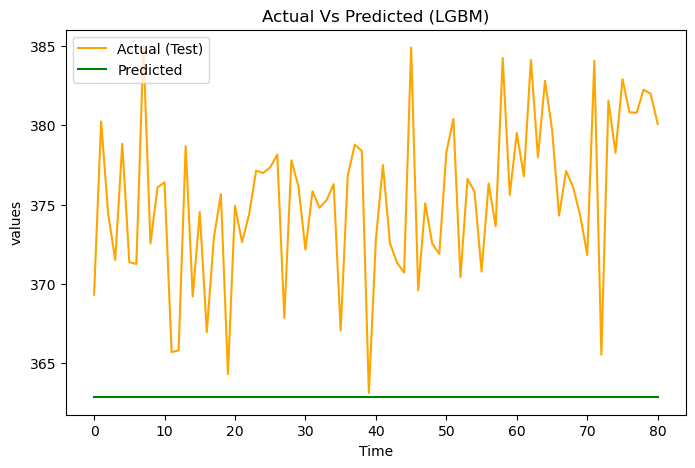

In [39]:
# Plotting graph for LGBMRegressor model

# Taking 80 values consideration for better view
plt.figure(figsize=(8,5))
plt.plot(y_test.iloc[:81].values, label="Actual (Test)", color="orange")
plt.plot(y_pred_lgbm[:81],label="Predicted",color="green")
plt.title("Actual Vs Predicted (LGBM)")
plt.xlabel("Time")
plt.ylabel("values")
plt.legend()
plt.show()

### Fitting Model With New Lagged Data Set: (LGBM)

In [40]:
lgbm_grid_new = GridSearchCV(model_lgbm,parameter,cv=tscv,scoring="r2")
lgbm_grid_new.fit(X_train_new,y_train_new)

,estimator,"LGBMRegressor...2, verbose=-1)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [41]:
y_pred_lgbm_new = lgbm_grid_new.predict(X_test_new)

# Evaluating models performance
evaluate(y_pred_lgbm_new,y_test_new)

Root_mean_squared_error is given by: 68.91203808362182
Mean_absolute_error is given by: 4748.868992838544
r2_score is given by: -2.265295573699697


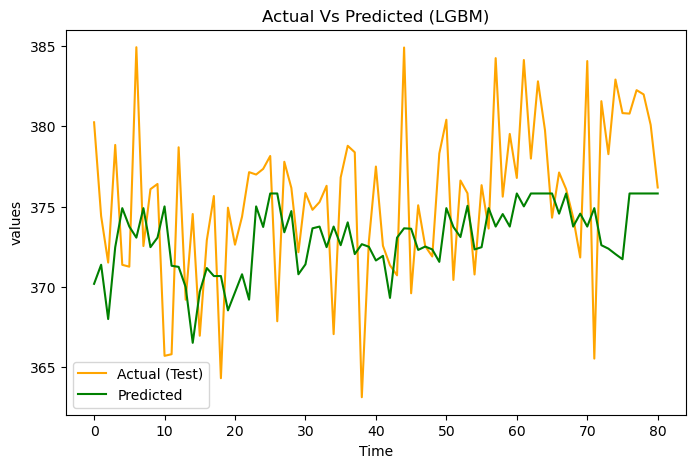

In [48]:
plt.figure(figsize=(8,5))
plt.plot(y_test_new.iloc[:81].values, label="Actual (Test)", color="orange")
plt.plot(y_pred_lgbm_new[:81],label="Predicted",color="green")
plt.title("Actual Vs Predicted (LGBM)")
plt.xlabel("Time")
plt.ylabel("values")
plt.legend()
plt.show()

### Prophet:

22:01:31 - cmdstanpy - INFO - Chain [1] start processing
22:02:14 - cmdstanpy - INFO - Chain [1] done processing


Test data size (Actuals): 10119
Forecast size (Predictions): 10119


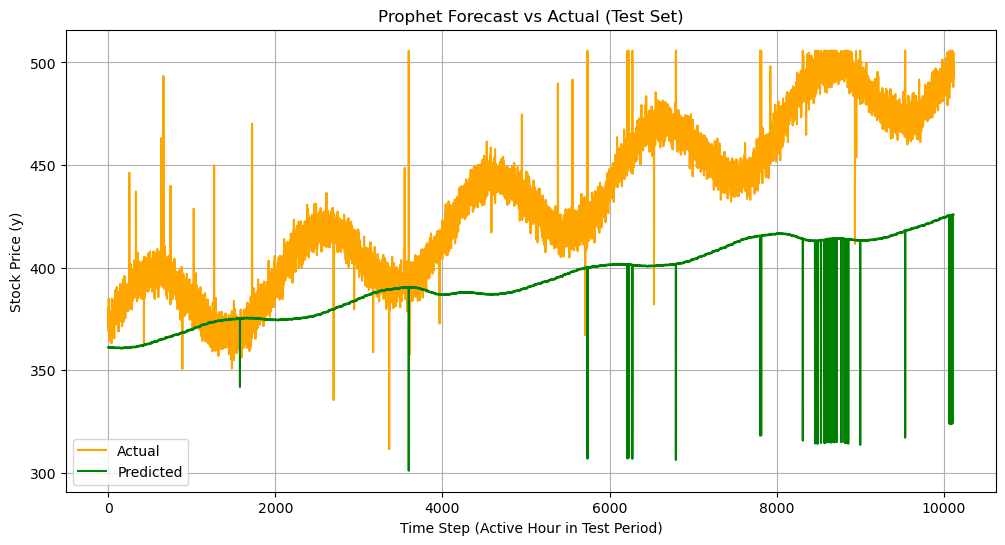

In [43]:
from prophet import Prophet

# Preparing prophet data
prophet_df = filtered_data[['stock_price', 'nasdaq_index']].reset_index().rename(
    columns={'timestamp': 'ds', 'stock_price': 'y'}
).copy()

# Train test data split for prophet
data_len = int(len(prophet_df)*0.8)
train = prophet_df.iloc[:data_len]
test = prophet_df.iloc[data_len:]

#Model building
model_prophet = Prophet()

# Adding exogenous_variable to the model
model_prophet.add_regressor("nasdaq_index") # As there is only one exogeneous variable.

model_prophet.fit(train)

future = test[['ds', "nasdaq_index" ]]

forecast = model_prophet.predict(future)


# We align the 'test' set to the 'forecast' dates to ensure they perfectly match.
test_aligned = test.set_index('ds').loc[forecast['ds']].reset_index()

# Chekcing wheher they have same data values or not
print(f"Test data size (Actuals): {len(test_aligned)}")
print(f"Forecast size (Predictions): {len(forecast)}")


# Compairing the actual test data with the predicted data----> using graph
plt.figure(figsize=(12, 6))
# Plotting actual 'y' values from the aligned test set
plt.plot(test_aligned["y"].values, label="Actual", color="orange")
# Plotting predicted 'yhat' values from the forecast
plt.plot(forecast["yhat"].values, label="Predicted", color="green")
plt.title("Prophet Forecast vs Actual (Test Set)")
plt.xlabel("Time Step (Active Hour in Test Period)")
plt.ylabel("Stock Price (y)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Understanding what is happening in between this range 
plt.figure(figsize=(12, 6))
# Plotting actual 'y' values from the aligned test set
plt.plot(test_aligned["y"].iloc[8500:9000], label="Actual", color="orange")
# Plotting predicted 'yhat' values from the forecast
plt.plot(forecast["yhat"].iloc[8500:9000], label="Predicted", color="green")
plt.title("Prophet Forecast vs Actual (Test Set)")
plt.xlabel("Time Step (Active Hour in Test Period)")
plt.ylabel("Stock Price (y)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#Using prophete we can also observe overall trend and weekly,yearly,daily flctuation.
model_prophet.plot_components(forecast)

In [ ]:
# Evaluating Modles
evaluate(test_aligned["y"],forecast["yhat"])

## Fitting Model With New Lagged Data Set: (Prophet)

In [44]:
# Making data set for the prophet model
new_prophet_df = new_data_set.reset_index().rename(columns={'timestamp':'ds','stock_price':'y'}).copy()

# Extracting all numerical varibales 
numerical_cols_ph = new_prophet_df.select_dtypes(include=["float64"]).columns.tolist()

# train test data split for prophet model
ln = int(len(new_prophet_df)*0.8)
train_ph = new_prophet_df.iloc[:ln]
test_ph = new_prophet_df.iloc[ln:]

# Model building
prophet_model = Prophet()

# Adding our lags and the nasdaq_index 
for col in [x for x in numerical_cols_ph if x != 'y']: # Because y is our target
    prophet_model.add_regressor(col)

# Training our model with train data
prophet_model.fit(train_ph)

22:02:35 - cmdstanpy - INFO - Chain [1] start processing
22:03:15 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
future_ph = test_ph[['ds','nasdaq_index','lag_1','lag_2','lag_3','lag_4']]

# Forecasting using new laged values 
forecast_ph = prophet_model.predict(future_ph)

# We align the 'test_ph' set to the 'forecast'_ph dates to ensure they perfectly match.
test_aligned_ph = test_ph.set_index('ds').loc[forecast_ph['ds']].reset_index()

# Chekcing wheher they have same data values or not
print(f"Test data size (Actuals): {len(test_aligned_ph)}")
print(f"Forecast size (Predictions): {len(forecast_ph)}")

Test data size (Actuals): 10118
Forecast size (Predictions): 10118


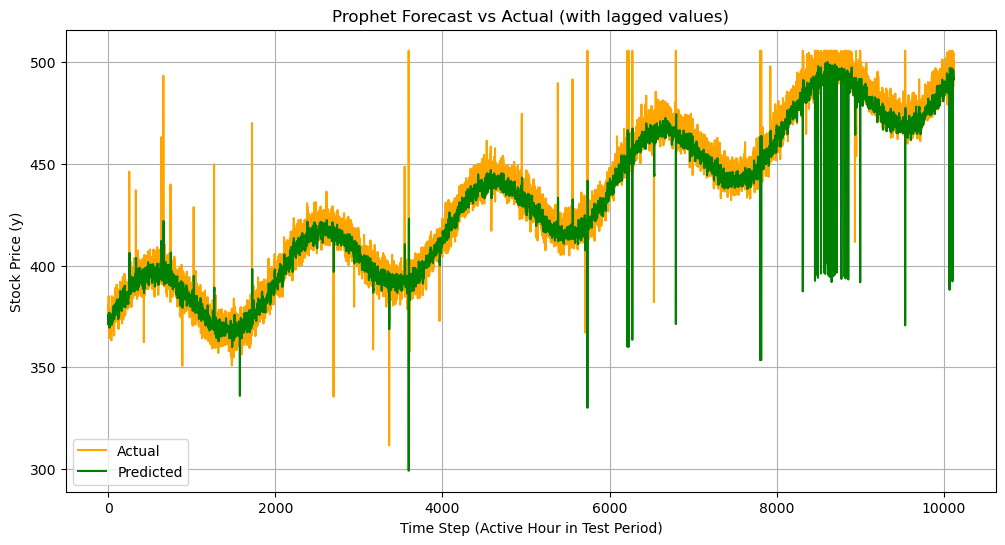

In [46]:
#Compairing the actual test data with the predicted data----> using graph
plt.figure(figsize=(12, 6))
# Plotting actual 'y' values from the aligned test set
plt.plot(test_aligned_ph["y"].values, label="Actual", color="orange")
# Plotting predicted 'yhat' values from the forecast
plt.plot(forecast_ph["yhat"].values, label="Predicted", color="green")
plt.title("Prophet Forecast vs Actual (with lagged values)")
plt.xlabel("Time Step (Active Hour in Test Period)")
plt.ylabel("Stock Price (y)")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# Evaluating Modles
evaluate(test_aligned_ph["y"],forecast_ph["yhat"])

Root_mean_squared_error is given by: 10.317492422532213
Mean_absolute_error is given by: 106.45064988900964
r2_score is given by: 0.9197856722136646


In [ ]:
forecast_ph

## DeepLearning Models:
#### LSTM (Long Short Term Memory):

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout

# Creating LSTM sequence
def make_sequence(X,y,time_steps=15): # default window means input gate 15
    Xs,ys = [],[]
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i+time_steps)])
        ys.append(y.iloc[i+time_steps])
    return np.array(Xs), np.array(ys)

# Making the function to check the model with different different parameters.
#units=64 means the LSTM layer has 64 hidden units, so the hidden state vector has 64 dimensions.
def model_builder(input_shape,units_input=64,units_output=32,activation='relu',dropout=0.2): 
    model = Sequential()
    model.add(LSTM(units_input,input_shape=input_shape,activation=activation,return_sequences=True))
    model.add(Dropout(dropout))
    model.add(LSTM(units_output,activation=activation))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


In [ ]:
time_steps = 18
X_seq_train, y_seq_train = make_sequence(X_train, y_train, time_steps)
X_seq_test, y_seq_test = make_sequence(X_test, y_test, time_steps)

"""
- If you have a fast computer check the LSTM model with different different parameter values.
- As,it is a deep learning model it will take too much time to run using cpu.
- so, please try with high values because high values gives best prediction.
- change, units_input, units_output,activation(relu,tanh),dropout=0.3 also epochs(20,50,,100 etc), batch_size(32,64,128,256 etc).
"""

# Changes the values of the parameters to check which is working well 
model_lstm =model_builder(input_shape=(X_seq_train.shape[1],X_seq_train.shape[2]),units_input=64,units_output=32,activation='relu',dropout=0.3)

#Model Training
history = model_lstm.fit(X_seq_train,y_seq_train,epochs=10,batch_size=32,verbose=1,validation_split=0.2)


In [ ]:
# Predicting output
y_pred_lstm = model_lstm(X_seq_test)

# Evaluation of model performance
evaluate(y_seq_test,y_pred_lstm)

In [ ]:
# Plotting actual vs predicted

plt.figure(figsize=(10,5))
plt.plot(y_seq_test[:200], label="Actual", color="orange")
plt.plot(y_pred_lstm[:200], label="Predicted", color="green")
plt.title("Actual vs Predicted (LSTM)")
plt.legend()
plt.show()

## Hybrid Models:

### ARIMA + Random Forest :

In [ ]:
model_arima = ARIMA(y_train_new,order=(1,1,0))
model_fit = model_arima.fit()

# Residuals
residuals = model_fit.resid


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

parameters = {      
    'max_depth': 10,             
    'min_samples_split': 2,        
    'min_samples_leaf': 4,         
    'max_features': 'sqrt'         
}
rf_model = RandomForestRegressor(**parameters)

param_grid= {
    'n_estimators': [200] 
}
grid_rf= GridSearchCV(rf_model,param_grid,cv=tscv,scoring='r2')
grid_rf.fit(X_train_new, residuals)

In [ ]:
# Arima model forecast
arima_forecast = model_fit.forecast(steps=len(y_test_new))

#RF predicts residuals same period
rf_residuals_pred = grid_rf.predict(X_test_new)

# Combinning both of them
hybrid_pred = arima_forecast + rf_residuals_pred

In [ ]:
evaluate(y_test_new.values,hybrid_pred)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_new.values, label="Actual", color="orange")
plt.plot(hybrid_pred.values, label="Hybrid Predicted", color="green")
plt.title("Hybrid Model (ARIMA + Random Forest)")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()

### SARIMA + Random Forest:

In [ ]:
sarima_model = SARIMAX(y_train_new, order=(1,1,0),seasonal_order=(1,1,0,16)) 
sarima_result = sarima_model.fit()

# resuduals
sarima_residuals = sarima_result.resid

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

parameters = {      
    'max_depth': 10,             
    'min_samples_split': 2,        
    'min_samples_leaf': 4,         
    'max_features': 'sqrt'         
}
rf_model = RandomForestRegressor(**parameters)

param_grid= {
    'n_estimators': [200] 
}
grid_rf_sr= GridSearchCV(rf_model,param_grid,cv=tscv,scoring='r2')
grid_rf_sr.fit(X_train_new, sarima_residuals)

In [ ]:
# Arima model forecast
sarima_forecast = sarima_result.forecast(steps=len(y_test_new))

#RF predicts residuals same period
rf_residuals_pred = grid_rf_sr.predict(X_test_new)

# Combinning both of them
hybrid_pred_sr = sarima_forecast + rf_residuals_pred

In [ ]:
# Model Evaluation
evaluate(y_test_new.values,hybrid_pred_sr)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_new.iloc[:100].values, label="Actual", color="orange")
plt.plot(hybrid_pred_sr.iloc[:100].values, label="Hybrid Predicted", color="green",linestyle="--")
plt.title("Hybrid Model (SARIMA + Random Forest)")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()

## SARIMA + XGBOOST :

In [ ]:
hybrid_xgb = XGBRegressor(eval_metric="rmse",random_state=42)

tscv = TimeSeriesSplit(n_splits=5) # Cross validation for time-series data 
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10],
    "learning_rate":[0.01,0.05,0.1,0.5]
}

"""
- Without repeating code again and again i used the residuals of the sarima directly here.
"""

hybrid_grid_xgb = GridSearchCV(hybrid_xgb,param_grid,cv=tscv,scoring="r2")
hybrid_grid_xgb.fit(X_train_new,sarima_residuals)

In [ ]:
xgb_residuals_pred = hybrid_grid_xgb.predict(X_test_new)

hybrid_xgb_sr = sarima_forecast + xgb_residuals_pred


In [ ]:
evaluate(y_test_new.values,hybrid_xgb_sr)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.iloc[:100].values, label="Actual", color="orange")
plt.plot(hybrid_xgb_sr.iloc[:100].values, label="Hybrid Predicted", color="green",linestyle="--")
plt.title("Hybrid Model (SARIMA + XGBOOST)")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()

### Prophet + XGBOOST:

In [ ]:
prophet_model.uncertainty_samples = 0

# Getting Prophet predictions on training data
train_pred = prophet_model.predict(train_ph[['ds','nasdaq_index','lag_1','lag_2','lag_3','lag_4']])

#Computing the residuals and adding a table as residuals in the train_ph data set
train_ph["residuals"] = train_ph['y'] - train_pred['yhat']

In [ ]:
# Preparing Features for the XGBOOST 

xgb_train = train_ph.copy()

# Final XGBOOST training dataset
X_train_xgb = xgb_train[["nasdaq_index"] + [f"lag_{lag}" for lag in range(1,5)]]

# y_train for the XGBOOST 
y_train_xgb = xgb_train["residuals"]


In [ ]:
hybrid_xgb_phx = XGBRegressor(eval_metric="rmse",random_state=42)

tscv = TimeSeriesSplit(n_splits=5) # Cross validation for time-series data 
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10],
    "learning_rate":[0.01,0.05,0.1,0.5]
}

hybrid_grid_phx = GridSearchCV(hybrid_xgb_phx,param_grid,cv=tscv,scoring="r2")
hybrid_grid_phx.fit(X_train_xgb,y_train_xgb)

In [ ]:
# Prophet forecast for the test set
prophet_forecast = prophet_model.predict(test_ph[['ds','nasdaq_index','lag_1','lag_2','lag_3','lag_4']])

# XGBOOST test dataset 
xgb_test = test_ph.copy()

X_test_xgb = xgb_test[['nasdaq_index'] + [f'lag_{i}' for i in range(1, 5)]]

# Predicting residuals
residual_pred_phx = hybrid_grid_phx.predict(X_test_xgb)

# Combine Prophet prediction and residual correction
hybrid_pred_phx = prophet_forecast['yhat'] + residual_pred_phx


In [ ]:
# Evalution of model
evaluate(y_test_new.values,hybrid_pred_phx)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", color="orange")
plt.plot(hybrid_pred_phx.values, label="Hybrid Predicted", color="green")
plt.title("Hybrid Model (Prophet + XGBOOST)")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()

## Final Model Building For Deployment:
```
- We checked all the models performance and we concluded that out of all the models, prophet model with lagged dataset is performing well as compared to others. Hence, we are going to take that model for the deployment.
- Before deployment we have to again train our selected model with all the data without splitting into train and test. The train and test split has been conducted just to check, how our model is working with unseen (means test data)  data.
```

In [ ]:
# Taking whole dataset as training the model
new_prophet_df

In [ ]:
nasdaq_df = new_prophet_df[["ds","nasdaq_index"]].rename(columns={"nasdaq_index":"y"})

# Train test split od nasdaq_index
ls = int(len(nasdaq_df)*0.8)
train_ns = nasdaq_df.iloc[:ls]
test_ns = nasdaq_df.iloc[ls:]

# Model Building
model_ns = Prophet(daily_seasonality=True, weekly_seasonality=True)

model_ns.fit(train_ns)

In [ ]:
futures_test = test_ns[["ds"]]

forecast_nasdaq = model_ns.predict(futures_test)

In [ ]:
y_actual = test_ns['y']
y_pred = forecast_nasdaq['yhat']


# Evalutions
print("\n<-------Evalution Metrics considering all the values----------->\n")
evaluate(y_pred,y_actual)
print("\n<-------Evalution Metrics for some values----------->\n")
evaluate(y_pred.head(480).values,y_actual.head(480).values) 

## Building Prophet model for predicting the nasdaq_index which is needed to predict stock_price:

In [ ]:
nasdaq_df.head(10)

In [ ]:
# Training the model with whole dataset
model_nasdaq = Prophet(daily_seasonality=True, weekly_seasonality=True)
model_nasdaq.fit(nasdaq_df)

In [ ]:
import pickle

with open("prophet_model_nasdaq.pkl","wb") as fl:
    pickle.dump(model_nasdaq, fl)

In [ ]:
future_hourly = model_nasdaq.make_future_dataframe(periods=16*30, freq='h') 
future_hourly = future_hourly[
    (future_hourly['ds'] > '2021-05-28 20:00:00') & 
    (future_hourly['ds'].dt.weekday < 5) &
    (future_hourly['ds'].dt.hour >= 4) &
    (future_hourly['ds'].dt.hour <= 20)
].reset_index(drop=True)


forecast = model_nasdaq.predict(future_hourly)


# View forecast
forecast[['ds','yhat', 'yhat_lower', 'yhat_upper']].head(20)

In [ ]:
new_prophet_df.head(10)

In [ ]:
numerical_cols_ph = new_prophet_df.select_dtypes(include=["float64"]).columns.tolist()


model_stock_price = Prophet()

# Adding our lags and the nasdaq_index 
for col in [x for x in numerical_cols_ph if x != 'y']: # Because y is our target
    model_stock_price.add_regressor(col)

# Training our model with whole dataset
model_stock_price.fit(new_prophet_df)

In [ ]:
with open("prophet_stock_model.pkl","wb") as f:
    pickle.dump(model_stock_price,f)